My plan so far is to hopefully compare two speeches if that follows guidelines of the assignment. I know the recommended source was books, but I think speeches either famous landmark speeches or possibly politician speeches could be interesting to compare. The politician speeches interest me as this is their way of expressing their campaign foundations and gaining support. I also considered some more famous speeches just to examine their entire content where possibly only portions of these speeches are more famous like MLK's "I have a dream" speech.

Link to the specches I used: https://www.presidency.ucsb.edu/documents/app-categories/spoken-addresses-and-remarks/presidential/state-the-union-addresses


In [5]:
import re
import operator
from collections import Counter

with open("Trump_SOA_01_30_18.txt", "r", encoding="utf-8") as f:
    speech1 = f.read()

with open("Trump_SOA_02_24_26.txt", "r", encoding="utf-8") as f:
    speech2 = f.read()

with open("Biden_SOA_03_01_22.txt", "r", encoding="utf-8") as f:
    speech3 = f.read()

Compare word frequencies between two works of a single author.

1.   Compare word frequencies between two works of a single author.
2. Are there some words preferred by one author but used less frequently by another author?
3.   Compare word frequencies between works of two authors.

Extra credit

The frequency of a specific word, e.g., "would" should follow a binomial distribution (each regular word in a document is a trial and with probability p that word is "would". The estimate for p is N("would")/N(regular word)). Do these binomial distributions for your chosen word differ significantly between books of the same author or between authors?

In [6]:
def remove_annotations(text):
    # Remove bracketed stage directions: [laughter], [applause], etc.
    text = re.sub(r'\[[^\]]*\]', '', text)
    return text

speech1_clean = remove_annotations(speech1)
speech2_clean = remove_annotations(speech2)
speech3_clean = remove_annotations(speech3)

In [7]:
def clean_tokens(word_freq_tuples):
    cleaned = {}
    for word, count in word_freq_tuples:
        word_clean = re.sub(r'[^\w\']', '', word.lower())
        if word_clean:
            cleaned[word_clean] = cleaned.get(word_clean, 0) + count
    return cleaned

stopwords = {
    "the", "to", "of", "we", "our", "in", "a",
    "that", "is", "are", "have", "for", "this",
    "will", "and", "on", "be", "it", "with",
    "as", "was", "by", "from", "their", "they", "has", "it's",
    "an", "at", "so", "were", "but"
}

wds = re.split(r'\s+', speech1_clean)
wds = clean_tokens(Counter(wds).most_common())

wf = {}
for w, count in wds.items():
    if w not in stopwords:
        wf[w] = count

wfs1 = sorted(wf.items(), key=operator.itemgetter(1), reverse=True)

ml = min(len(wfs1), 20)
for i in range(ml):
    print(wfs1[i][0] + "\t" + str(wfs1[i][1]))

you	47
i	36
people	32
american	31
who	29
all	28
he	28
great	26
very	24
americans	24
tonight	23
one	22
america	22
new	21
thank	21
can	20
more	20
his	20
us	19
them	19


In [8]:
stopwords = {
    "the", "to", "of", "we", "our", "in", "a",
    "that", "is", "are", "have", "for", "this",
    "will", "and", "on", "be", "it", "with",
    "as", "was", "by", "from", "their", "they", "has", "it's",
    "an", "at", "so", "were", "but"
}

wds = re.split(r'\s+', speech2_clean)
wds = clean_tokens(Counter(wds).most_common())

wf = {}
for w, count in wds.items():
    if w not in stopwords:
        wf[w] = count

wfs2 = sorted(wf.items(), key=operator.itemgetter(1), reverse=True)

ml = min(len(wfs2), 20)
for i in range(ml):
    print(wfs2[i][0] + "\t" + str(wfs2[i][1]))

you	120
i	114
all	59
very	55
thank	47
one	45
no	42
people	41
not	40
she	39
great	38
up	37
going	36
president	36
just	35
her	35
he	35
we're	35
them	33
american	32


In [9]:
stopwords = {
    "the", "to", "of", "we", "our", "in", "a",
    "that", "is", "are", "have", "for", "this",
    "will", "and", "on", "be", "it", "with",
    "as", "was", "by", "from", "their", "they", "has", "it's",
    "an", "at", "so", "were", "but"
}

wds = re.split(r'\s+', speech3_clean)
wds = clean_tokens(Counter(wds).most_common())

wf = {}
for w, count in wds.items():
    if w not in stopwords:
        wf[w] = count

wfs3 = sorted(wf.items(), key=operator.itemgetter(1), reverse=True)

ml = min(len(wfs3), 20)
for i in range(ml):
    print(wfs3[i][0] + "\t" + str(wfs3[i][1]))

you	69
i	66
more	43
america	39
can	36
my	30
americans	30
not	28
all	28
people	28
we're	27
do	26
up	26
american	25
get	25
your	24
he	24
world	24
year	24
who	23


TASK **1**

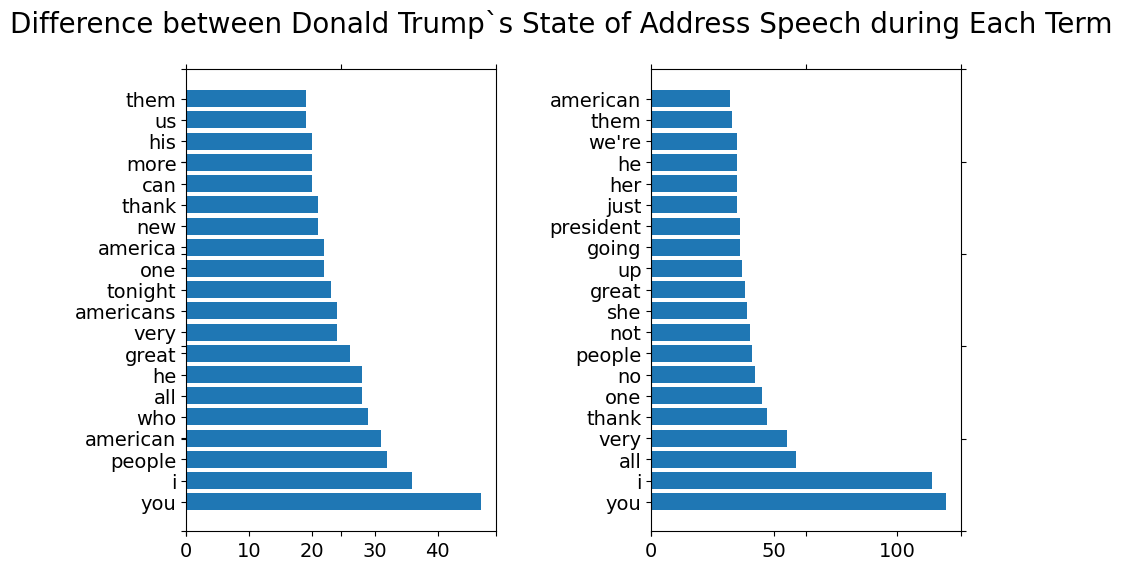

In [10]:
#Plot the results: are there striking differences in language?
import numpy as np
import pylab
import matplotlib.pyplot as plt

%matplotlib inline
def plotTwoLists (wf_ee, wf_bu, title):
    f = plt.figure (figsize=(10, 6))
    # this is painfully tedious....
    f .suptitle (title, fontsize=20)
    ax = f.add_subplot(111)
    ax .spines ['top'] .set_color ('none')
    ax .spines ['bottom'] .set_color ('none')
    ax .spines ['left'] .set_color ('none')
    ax .spines ['right'] .set_color ('none')
    ax .tick_params (labelcolor='w', top='off', bottom='off', left='off', right='off', labelsize=20)

    # Create two subplots, this is the first one
    ax1 = f .add_subplot (121)
    plt .subplots_adjust (wspace=.5)

    pos = np .arange (len(wf_ee))
    ax1 .tick_params (axis='both', which='major', labelsize=14)
    pylab .yticks (pos, [ x [0] for x in wf_ee])
    ax1 .barh (range(len(wf_ee)), [ x [1] for x in wf_ee ], align='center')

    ax2 = f .add_subplot (122)
    ax2 .tick_params (axis='both', which='major', labelsize=14)
    pos = np .arange (len(wf_bu))
    pylab .yticks (pos, [ x [0] for x in wf_bu ])
    ax2 .barh (range (len(wf_bu)), [ x [1] for x in wf_bu ], align='center')

plotTwoLists(wfs1[:20], wfs2[:20], 'Difference between Donald Trump`s State of Address Speech during Each Term')

In [11]:
relative1 = {}
relative2 = {}

# Total number of words in each speech
total1 = sum(word_tuple[1] for word_tuple in wfs1)
total2 = sum(word_tuple[1] for word_tuple in wfs2)

# Calculate relative frequency for Speech 1
for word_tuple in wfs1:
    word = word_tuple[0]
    count = word_tuple[1]
    relative1[word] = count / total1

# Calculate relative frequency for Speech 2
for word_tuple in wfs2:
    word = word_tuple[0]
    count = word_tuple[1]
    relative2[word] = count / total2

# Get all words appearing in either speech
all_words = set(relative1) | set(relative2)

# Calculate the difference in relative frequency
differences = {}

for word in all_words:
    differences[word] = relative1.get(word, 0) - relative2.get(word, 0)

print(differences)

{'era': 0.00026198585276395077, 'shutdown': -0.0001401541695865452, 'after': 3.0219251131707175e-05, 'searing': -0.0001401541695865452, '263': -0.0001401541695865452, 'lizbeth': -0.0001401541695865452, 'cuevas': 0.0005239717055279015, 'election': 0.00026198585276395077, 'athletes': -0.0002803083391730904, '1900': -0.0001401541695865452, 'sacrifice': 0.0005239717055279015, 'crisis': 0.00012183168317740558, 'learning': -0.0001401541695865452, 'electionthink': -0.0001401541695865452, 'homes': -0.0005606166783461808, 'montha': 0.00026198585276395077, 'package': 0.00026198585276395077, 'no': -0.0035286024477593414, 'minnesota': -0.0002803083391730904, 'rose': 0.00026198585276395077, 'anymore': -0.0004204625087596356, 'crooked': -0.0001401541695865452, 'corey': 0.0013099292638197536, 'overwhelmed': -0.0001401541695865452, 'sp': -0.0001401541695865452, 'successful': -0.0004204625087596356, 'went': 0.00038381753594135635, 'wantsnobody': -0.0001401541695865452, 'cartel': -0.0001401541695865452,

In [12]:
sorted_differences = sorted(
    differences.items(),
    key=lambda x: x[1],
    reverse=True
)

print("Words more common in Speech 1:")
for word, difference in sorted_differences[:20]:
    print(word, round(difference, 5))

print("\nWords more common in Speech 2:")
for word, difference in sorted_differences[-20:]:
    print(word, round(difference, 5))

Words more common in Speech 1:
american 0.00364
who 0.00325
americans 0.00306
new 0.00284
america 0.00282
tonight 0.0028
together 0.00271
people 0.00264
can 0.00258
he 0.00243
us 0.00231
work 0.0023
tax 0.00211
these 0.00211
workers 0.0021
building 0.00196
family 0.00192
ryan 0.00183
veterans 0.00183
am 0.00182

Words more common in Speech 2:
that's -0.00204
before -0.00205
first -0.00209
really -0.00212
they're -0.00226
big -0.00226
say -0.00266
even -0.00268
said -0.00272
up -0.00335
got -0.00338
i'm -0.00342
going -0.00347
no -0.00353
we're -0.0036
her -0.00386
she -0.00389
president -0.004
you -0.00451
i -0.00655


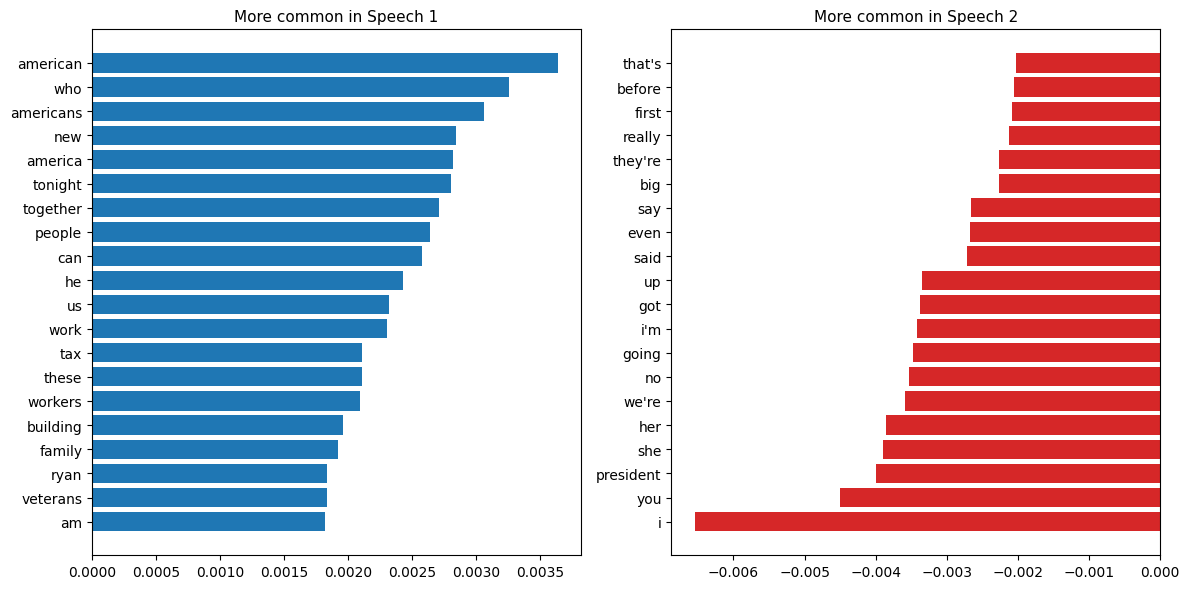

In [14]:
n = 20
top_speech1 = sorted_differences[:n]
top_speech2 = sorted_differences[-n:]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))
ax1.barh([w for w, d in reversed(top_speech1)], [d for w, d in reversed(top_speech1)], color='#1f77b4')
ax1.set_title('More common in Speech 1', fontsize=11)
ax2.barh([w for w, d in reversed(top_speech2)], [d for w, d in reversed(top_speech2)], color='#d62728')
ax2.set_title('More common in Speech 2', fontsize=11)
for ax in (ax1, ax2):
    ax.tick_params(labelsize=10)
plt.tight_layout()
plt.savefig('distinctive_words_split.png', dpi=300, bbox_inches='tight')
plt.show()

First speech more focused on americans as a whole, taxes, workers, veterans, etc -> setting goals and addressing certain groups. Ryan is an american police officer who adopted a child in need. Trump used the story to emphasize the goodness in America in order to speak on "preserving" that by requesting more military funding.

Second seems more narrative and speaking to audience in a more informal way. Most of prounouns came from stories about different Americans that he used to highlight issues he planned to tackle. For example, Sarah Beckstrom story used to highlight a security/military issue. He also introduced the hockey team for a significant portion of his introductions which explains some of these frequent words.

TASK **2 & 3**

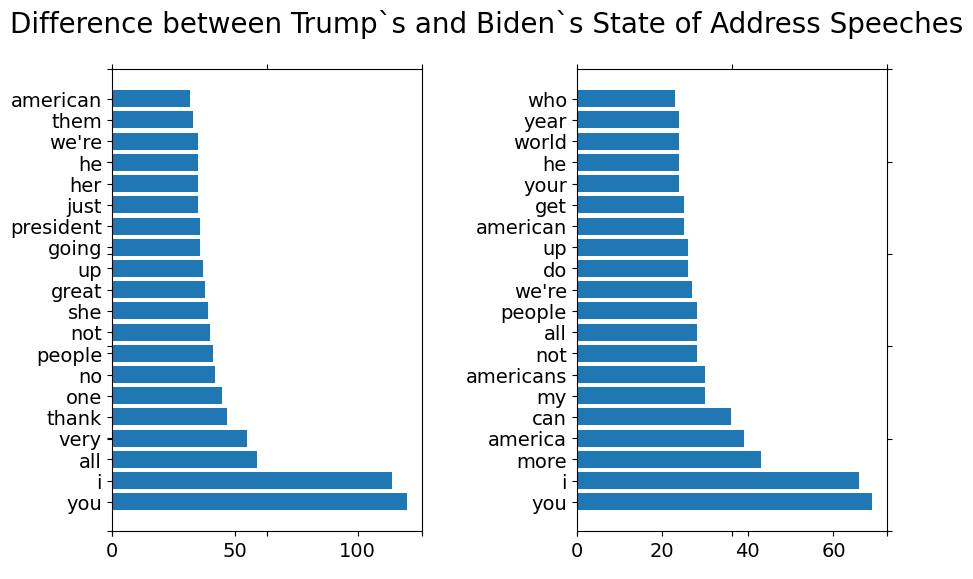

In [15]:
#Plot the results: are there striking differences in language?
import numpy as np
import pylab
import matplotlib.pyplot as plt

%matplotlib inline
def plotTwoLists (wf_ee, wf_bu, title):
    f = plt.figure (figsize=(10, 6))
    # this is painfully tedious....
    f .suptitle (title, fontsize=20)
    ax = f.add_subplot(111)
    ax .spines ['top'] .set_color ('none')
    ax .spines ['bottom'] .set_color ('none')
    ax .spines ['left'] .set_color ('none')
    ax .spines ['right'] .set_color ('none')
    ax .tick_params (labelcolor='w', top='off', bottom='off', left='off', right='off', labelsize=20)

    # Create two subplots, this is the first one
    ax1 = f .add_subplot (121)
    plt .subplots_adjust (wspace=.5)

    pos = np .arange (len(wf_ee))
    ax1 .tick_params (axis='both', which='major', labelsize=14)
    pylab .yticks (pos, [ x [0] for x in wf_ee])
    ax1 .barh (range(len(wf_ee)), [ x [1] for x in wf_ee ], align='center')

    ax2 = f .add_subplot (122)
    ax2 .tick_params (axis='both', which='major', labelsize=14)
    pos = np .arange (len(wf_bu))
    pylab .yticks (pos, [ x [0] for x in wf_bu ])
    ax2 .barh (range (len(wf_bu)), [ x [1] for x in wf_bu ], align='center')

plotTwoLists(wfs2[:20], wfs3[:20], 'Difference between Trump`s and Biden`s State of Address Speeches')

In [16]:
relative1 = {}
relative2 = {}

# Total number of words in each speech
total1 = sum(word_tuple[1] for word_tuple in wfs2)
total2 = sum(word_tuple[1] for word_tuple in wfs3)

# Calculate relative frequency for Speech 1
for word_tuple in wfs2:
    word = word_tuple[0]
    count = word_tuple[1]
    relative1[word] = count / total1

# Calculate relative frequency for Speech 2
for word_tuple in wfs3:
    word = word_tuple[0]
    count = word_tuple[1]
    relative2[word] = count / total2

# Get all words appearing in either speech
all_words = set(relative1) | set(relative2)

# Calculate the difference in relative frequency
differences = {}

for word in all_words:
    differences[word] = relative1.get(word, 0) - relative2.get(word, 0)

print(differences)

{'era': -0.00019252984212552945, 'shutdown': -5.237567253898426e-05, 'countless': -0.00019252984212552945, 'after': 1.4571284477616058e-06, 'searing': 0.0001401541695865452, '263': 0.0001401541695865452, 'lizbeth': 0.0001401541695865452, 'election': -0.00019252984212552945, 'formed': -0.00019252984212552945, 'pat': -0.0009626492106276473, 'airports': -0.0003850596842510589, 'athletes': 0.0002803083391730904, '1900': 0.0001401541695865452, 'crisis': -0.00043743535679004316, 'learning': -5.237567253898426e-05, 'electionthink': 0.0001401541695865452, 'homes': -1.6972848030407587e-05, 'solar': -0.00019252984212552945, 'competition': -0.0007701193685021178, 'fuel': -0.00019252984212552945, 'no': 0.004153706543505133, 'minnesota': 0.0002803083391730904, "'rust": -0.00019252984212552945, 'anymore': 0.0004204625087596356, 'crooked': 0.0001401541695865452, 'overwhelmed': 0.0001401541695865452, 'sp': 0.0001401541695865452, 'successful': 0.0004204625087596356, 'went': -0.00043743535679004316, 'wa

In [17]:
sorted_differences = sorted(
    differences.items(),
    key=lambda x: x[1],
    reverse=True
)

print("Words more common in Speech 1 - DT:")
for word, difference in sorted_differences[:20]:
    print(word, round(difference, 5))

print("\nWords more common in Speech 2 - JB:")
for word, difference in sorted_differences[-20:]:
    print(word, round(difference, 5))

Words more common in Speech 1 - DT:
very 0.00598
she 0.00508
her 0.00471
great 0.00436
no 0.00415
you 0.00353
thank 0.00351
i 0.00327
got 0.00326
said 0.00293
all 0.00288
one 0.00265
before 0.00259
country 0.00242
even 0.00237
just 0.00221
now 0.00217
believe 0.00214
want 0.00212
first 0.002

Words more common in Speech 2 - JB:
make -0.00213
need -0.00217
jobs -0.00219
other -0.00227
pass -0.00233
we've -0.00247
plan -0.00252
americans -0.00255
families -0.00256
costs -0.00256
know -0.00261
folks -0.00289
your -0.00308
we'll -0.00313
get -0.00327
look -0.00362
let's -0.00376
more -0.00393
can -0.00427
america -0.00457


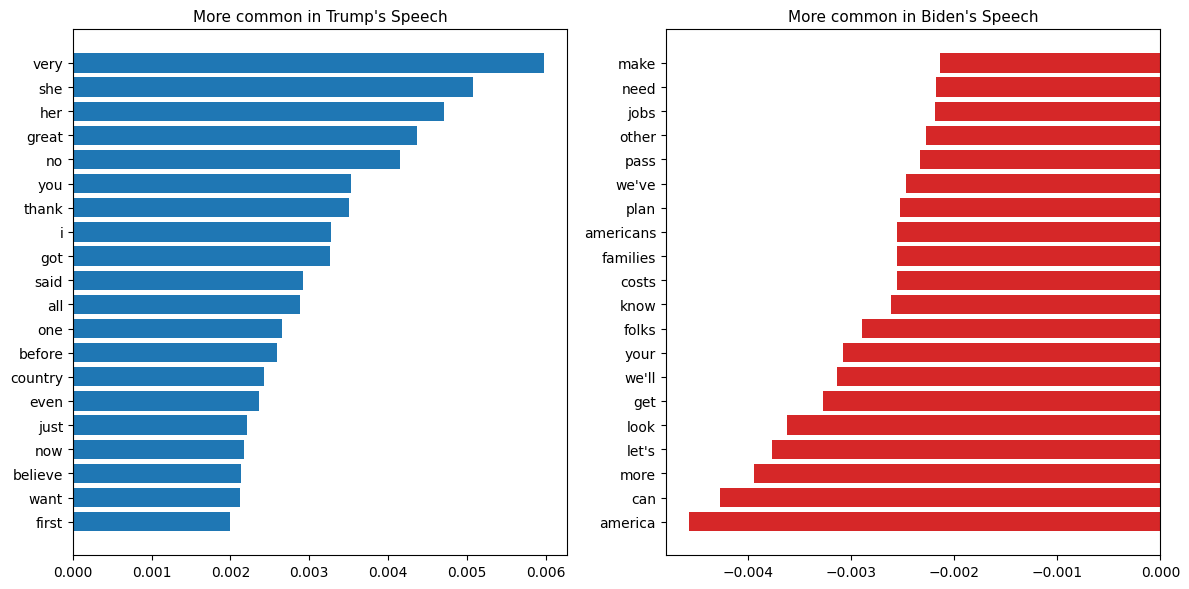

In [18]:
import matplotlib.pyplot as plt

sorted_differences = sorted(
    differences.items(),
    key=lambda x: x[1],
    reverse=True
)

n = 20
top_speech1 = sorted_differences[:n]   # Trump
top_speech2 = sorted_differences[-n:]  # Biden

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))

ax1.barh([w for w, d in reversed(top_speech1)], [d for w, d in reversed(top_speech1)], color='#1f77b4')
ax1.set_title("More common in Trump's Speech", fontsize=11)

ax2.barh([w for w, d in reversed(top_speech2)], [d for w, d in reversed(top_speech2)], color='#d62728')
ax2.set_title("More common in Biden's Speech", fontsize=11)

for ax in (ax1, ax2):
    ax.tick_params(labelsize=10)

plt.tight_layout()
plt.savefig('distinctive_words_split.png', dpi=300, bbox_inches='tight')
plt.show()

Biden speaks on families, plans, pass which is most likely referring to bills/plans, etc for his term. He speaks on costs also which again is most likely relating to the previous words. He also uses "we" and "let's" more to convince audience to view him as a teammate. Lastly, he uses "can" and "more" which signify the aspiration of the speech.

Trump again in his speech is using more second person pronouns as if story telling which is common for presidents to include as part of guest recognition. He is also using words like "belief" and "great" which may be used to position himself or his plans in a positive light to gain support.

In [34]:
import numpy as np
from statsmodels.stats.proportion import proportions_ztest

def test_word(word, count1, total1, count2, total2):
    counts = np.array([count1, total1])
    n = np.array([total1, total2])

    # Using statsmodels' two-sample proportions z-test
    stat, pval = proportions_ztest(
        count=[count1, count2],
        nobs=[total1, total2]
    )

    p1 = count1 / total1
    p2 = count2 / total2
    print(f"Word: '{word}'")
    print(f"  Speech 1: {count1}/{total1} = {p1:.5f}")
    print(f"  Speech 2: {count2}/{total2} = {p2:.5f}")
    print(f"  z-statistic: {stat:.3f}")
    print(f"  p-value: {pval:.5f}")
    if pval < 0.05:
        print("  --> Significant difference (p < 0.05)")
    else:
        print("  --> Not significantly different (p >= 0.05)")


# Compare Trump's speeches to each other
target_word = "i"

# Convert wfs1 and wfs2 (list of tuples) into dictionaries for easy lookup
wf_dict1 = dict(wfs1)
wf_dict2 = dict(wfs2)

count1 = wf_dict1.get(target_word, 0)
total1 = sum(word_tuple[1] for word_tuple in wfs1)
count2 = wf_dict2.get(target_word, 0)
total2 = sum(word_tuple[1] for word_tuple in wfs2)

test_word(target_word, count1, total1, count2, total2)

Word: 'i'
  Speech 1: 36/3817 = 0.00943
  Speech 2: 114/7135 = 0.01598
  z-statistic: -2.809
  p-value: 0.00498
  --> Significant difference (p < 0.05)


In [31]:
# Compare Trump's(speech 1) more recent speech to Biden's(speech 2)
target_word = "i"

# Convert wfs1 and wfs2 (list of tuples) into dictionaries for easy lookup
wf_dict1 = dict(wfs2)
wf_dict2 = dict(wfs3)

count1 = wf_dict1.get(target_word, 0)
total1 = sum(word_tuple[1] for word_tuple in wfs2)
count2 = wf_dict2.get(target_word, 0)
total2 = sum(word_tuple[1] for word_tuple in wfs3)

test_word(target_word, count1, total1, count2, total2)

Word: 'i'
  Speech 1: 114/7135 = 0.01598
  Speech 2: 66/5194 = 0.01271
  z-statistic: 1.495
  p-value: 0.13492
  --> Not significantly different (p >= 0.05)


It seemed Biden used a lot of "team-focused" words in his speech, so I wanted to compare a few words to see if I could spot something along those lines. I decided to test the word "i" across all three speeches. Interestingly, there wasn't much difference between Trump's most recent term SOTU and Biden's (p = 0.135), but Trump himself shifted his use of "i" significantly between his own two terms (p = 0.005), using it notably more in his second-term address.

In [43]:
# Compare Trump's(speech 1) more recent speech to Biden's(speech 2)
target_word = "jobs"

# Convert wfs1 and wfs2 (list of tuples) into dictionaries for easy lookup
wf_dict1 = dict(wfs2)
wf_dict2 = dict(wfs3)

count1 = wf_dict1.get(target_word, 0)
total1 = sum(word_tuple[1] for word_tuple in wfs2)
count2 = wf_dict2.get(target_word, 0)
total2 = sum(word_tuple[1] for word_tuple in wfs3)

test_word(target_word, count1, total1, count2, total2)

Word: 'jobs'
  Speech 1: 5/7135 = 0.00070
  Speech 2: 15/5194 = 0.00289
  z-statistic: -2.980
  p-value: 0.00289
  --> Significant difference (p < 0.05)


I wanted to find a word that differed between Biden and Trump specifically, so I tested a few more major concepts like immigration, economy, inflation, etc. I found that the word "jobs" was used more by Biden (15/5,194) than Trump (5/7,135), with a p-value of 0.003. I think this again reflects Biden's agenda by promising those watching an increase in jobs.